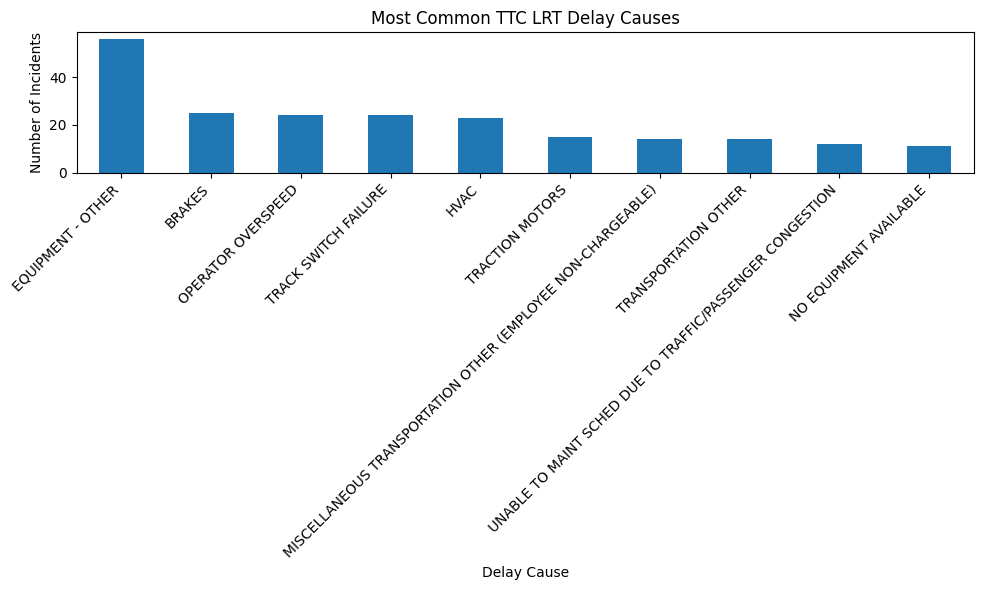

In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

DELAYS_PATH = Path("..") / "dataset" / "TTC_LRT_Delays.csv"
CODES_PATH  = Path("..") / "dataset" / "Code Descriptions.csv"

delays = pd.read_csv(DELAYS_PATH)
codes  = pd.read_csv(CODES_PATH)

delays.columns = delays.columns.str.strip()
codes.columns  = codes.columns.str.strip()

codes = codes.rename(columns={"CODE": "Code", "DESCRIPTION": "Description"})

if "Code" not in delays.columns:
    raise ValueError(f"'Code' column not found in delays file. Columns: {list(delays.columns)}")
if "Code" not in codes.columns:
    raise ValueError(f"'Code' column not found in code descriptions file. Columns: {list(codes.columns)}")

delays["Code"] = delays["Code"].astype(str).str.strip()
codes["Code"]  = codes["Code"].astype(str).str.strip()

merged = delays.merge(codes[["Code", "Description"]], on="Code", how="left")


merged["Cause Label"] = merged["Description"].fillna(merged["Code"])


top_causes = merged["Cause Label"].value_counts().head(10)

plt.figure(figsize=(10, 6))
top_causes.plot(kind="bar")
plt.xlabel("Delay Cause")
plt.ylabel("Number of Incidents")
plt.title("Most Common TTC LRT Delay Causes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()

plt.savefig("viz_2_delay_causes.png", dpi=300)
plt.show()
